In [1]:
import os
import glob

import pandas as pd

import fiftyone as fo

from tator_tools.download_media import MediaDownloader
from tator_tools.fiftyone_clustering import FiftyOneDatasetViewer
from tator_tools.download_query import QueryDownloader
from tator_tools.yolo_dataset import YOLODataset
from tator_tools.yolo_crop_regions import YOLORegionCropper
from tator_tools.train_model import ModelTrainer
from tator_tools.inference_video import VideoInferencer

from yolo_tiler import YoloTiler, TileConfig

In [ ]:
# coral, sponge 55040
"eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJtZXRob2QiOiJPUiIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoicG9uZyJ9LHsiYXR0cmlidXRlIjoiU2NpZW50aWZpY05hbWUiLCJvcGVyYXRpb24iOiJpY29udGFpbnMiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOiJ0aGVzZWEifSx7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoic3dpZnRpYSJ9LHsiYXR0cmlidXRlIjoiU2NpZW50aWZpY05hbWUiLCJvcGVyYXRpb24iOiJpY29udGFpbnMiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOiJzdGljaG9wIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6Im11cmljZWEifSx7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoibWFkcmVwb3JhIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6Im1hZHJhY2lzIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6ImVsbGlzZWxsIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6ImJlYnJ5Y2UifSx7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoiYW50aXBhdGhlcyBmdXJjYXRhIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6ImFudGlwYXRoZXMgYXRsYW50aWNhIn0seyJhdHRyaWJ1dGUiOiJDb21tb25OYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoic3RhciJ9XX0seyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjQyOH0seyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjM1Mn0seyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjMwOX0seyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjQ2NX0seyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjU1N30seyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjExOTN9LHsiYXR0cmlidXRlIjoiJHZlcnNpb24iLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOnRydWUsInZhbHVlIjoyMjh9XX0seyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiJJbmRpdmlkdWFsQ291bnQiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6IjEifV19LHsibWV0aG9kIjoiT1IiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkdHlwZSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoyNDd9XX1dfQ=="

# Download Query from Tator

In [2]:
# Set parameters
api_token = os.getenv("TATOR_TOKEN")
project_id = 70  # 155

# Search string comes from Tator's Data Metadata Export utility
search_string = "eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJtZXRob2QiOiJPUiIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoicG9uZyJ9LHsiYXR0cmlidXRlIjoiU2NpZW50aWZpY05hbWUiLCJvcGVyYXRpb24iOiJpY29udGFpbnMiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOiJ0aGVzZWEifSx7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoic3dpZnRpYSJ9LHsiYXR0cmlidXRlIjoiU2NpZW50aWZpY05hbWUiLCJvcGVyYXRpb24iOiJpY29udGFpbnMiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOiJzdGljaG9wIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6Im11cmljZWEifSx7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoibWFkcmVwb3JhIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6Im1hZHJhY2lzIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6ImVsbGlzZWxsIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6ImJlYnJ5Y2UifSx7ImF0dHJpYnV0ZSI6IlNjaWVudGlmaWNOYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoiYW50aXBhdGhlcyBmdXJjYXRhIn0seyJhdHRyaWJ1dGUiOiJTY2llbnRpZmljTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6ImFudGlwYXRoZXMgYXRsYW50aWNhIn0seyJhdHRyaWJ1dGUiOiJDb21tb25OYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoic3RhciJ9XX0seyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjQyOH0seyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjM1Mn0seyJhdHRyaWJ1dGUiOiIkY3JlYXRlZF9ieSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjMwOX0seyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjQ2NX0seyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjU1N30seyJhdHRyaWJ1dGUiOiIkdmVyc2lvbiIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOjExOTN9LHsiYXR0cmlidXRlIjoiJHZlcnNpb24iLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOnRydWUsInZhbHVlIjoyMjh9XX0seyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiJJbmRpdmlkdWFsQ291bnQiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6IjEifV19LHsibWV0aG9kIjoiT1IiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkdHlwZSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoyNDd9XX1dfQ=="

# Demo for downloading labeled data
frac = 0.25

dataset_name = "MDBC_Transects_Coral_Sponges"
output_dir = "E:/JordanP/Click-a-Coral/data/reduced"

label_field = ["ScientificName", "CommonName", "PercentCover", "IndividualCount"]

In [3]:
# Create a downloader for the labeled data
downloader = QueryDownloader(api_token,
                             project_id=project_id,
                             search_string=search_string,
                             frac=frac,
                             output_dir=output_dir,
                             dataset_name=dataset_name,
                             label_field=label_field,
                             download_width=1024)

NOTE: Authentication successful for jordan.pierce
NOTE: Search string saved to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\search_string.txt


In [4]:
# Download the labeled data
downloader.download_data()

NOTE: Querying Tator for labeled data
NOTE: Found 59272 objects in query


Processing query: 100%|██████████| 59272/59272 [00:03<00:00, 15983.72it/s]


NOTE: Found 14974 query objects after sampling
NOTE: Data saved to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\data.csv
NOTE: Data saved to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\data.json
NOTE: Downloading images to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\images


Retrying download for media 9432690, frame 0 again...


Retrying download for media 9432690, frame 0 again...


Error downloading E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\images\9432690_0.jpg: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


NOTE: Images downloaded to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\images


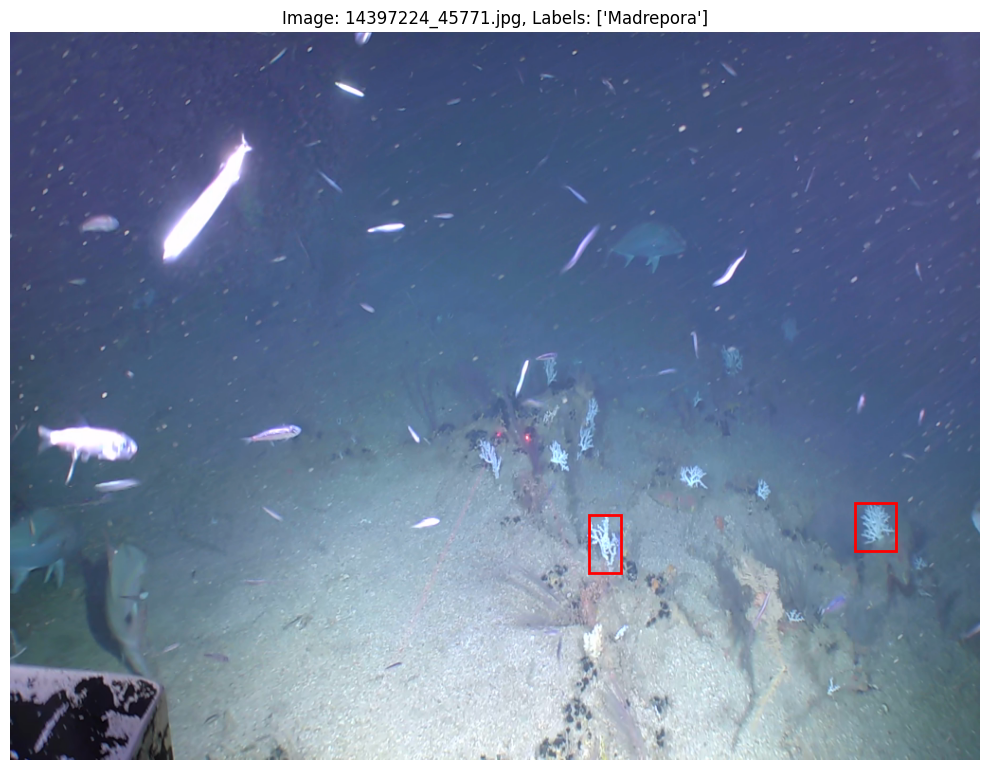

In [10]:
downloader.display_sample(label_column="ScientificName")

In [11]:
df = downloader.as_dataframe()  # .as_dict()

# Drop any rows without bounding boxes
df = df.dropna(subset=["x", "y", "width", "height"])

# Convert the ScientificNames
df.loc[df['ScientificName'].str.contains("atlantica", case=False, na=False), 'ScientificName'] = "ANTIPATHES_ATLANTICA"
df.loc[df['ScientificName'].str.contains("furcata", case=False, na=False), 'ScientificName'] = "ANTIPATHES_FURCATA"
df.loc[df['ScientificName'].str.contains("bebryce", case=False, na=False), 'ScientificName'] = "BEBRYCE"
df.loc[df['ScientificName'].str.contains("elli", case=False, na=False), 'ScientificName'] = "WHIP"
df.loc[df['ScientificName'].str.contains("madracis", case=False, na=False), 'ScientificName'] = "MADRACIS"
df.loc[df['ScientificName'].str.contains("madrepora", case=False, na=False), 'ScientificName'] = "MADREPORA"
df.loc[df['ScientificName'].str.contains("muricea", case=False, na=False), 'ScientificName'] = "MURICEA_PENDULA"
df.loc[df['ScientificName'].str.contains("paramuri", case=False, na=False), 'ScientificName'] = "PARAMURICEA"
df.loc[df['ScientificName'].str.contains("stichopathes", case=False, na=False), 'ScientificName'] = "WHIP"
df.loc[df['ScientificName'].str.contains("swiftia", case=False, na=False), 'ScientificName'] = "SWIFTIA_EXERTA"
df.loc[df['ScientificName'].str.contains("thesea", case=False, na=False), 'ScientificName'] = "THESEA_NIVEA"
df.loc[df['CommonName'].str.contains("star", case=False, na=False), 'ScientificName'] = "CRINOID_STAR"
df.loc[df['CommonName'].str.contains("pong", case=False, na=False), 'ScientificName'] = "SPONGE"
df.loc[df['ScientificName'].str.contains("pong", case=False, na=False), 'ScientificName'] = "SPONGE"


# Update the label field to be the ScientificName
df['label'] = df['ScientificName']

print(df.shape, df.columns)

df.sample(10) 

(14783, 16) Index(['media', 'frame', 'image_name', 'image_path', 'image_width',
       'image_height', 'x', 'y', 'width', 'height', 'polygon',
       'ScientificName', 'CommonName', 'PercentCover', 'IndividualCount',
       'label'],
      dtype='object')


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,media,frame,image_name,image_path,image_width,image_height,x,y,width,height,polygon,ScientificName,CommonName,PercentCover,IndividualCount,label
2077,14407606,120137,14407606_120137.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.544669,0.727970,0.134158,0.267169,[],ANTIPATHES_FURCATA,black coral,NaN,1.0,ANTIPATHES_FURCATA
10025,6803318,131625,6803318_131625.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.762581,0.419725,0.212940,0.550646,[],WHIP,gorgonian coral,NaN,1.0,WHIP
12116,6841602,83080,6841602_83080.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.010417,0.407407,0.219371,0.586541,[],SWIFTIA_EXERTA,Gorgonian,NaN,1.0,SWIFTIA_EXERTA
12225,6841602,62675,6841602_62675.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.209905,0.448838,0.057266,0.062741,[],SPONGE,demosponge,NaN,1.0,SPONGE
13685,9452702,139722,9452702_139722.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.166087,0.800618,0.216726,0.146604,[],WHIP,black coral,NaN,1.0,WHIP
10148,6756696,50806,6756696_50806.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.422396,0.570370,0.073735,0.175807,[],ANTIPATHES_FURCATA,Antipathes,NaN,1.0,ANTIPATHES_FURCATA
10343,6756696,151478,6756696_151478.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.343594,0.548817,0.069948,0.091924,[],WHIP,Sea whip,NaN,1.0,WHIP
7037,6761625,120049,6761625_120049.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.679110,0.929379,0.026098,0.045621,[],SPONGE,Axinellidae?,NaN,1.0,SPONGE
9448,6787327,87096,6787327_87096.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.444444,0.829885,0.090451,0.154374,[],ANTIPATHES_FURCATA,black coral,NaN,1.0,ANTIPATHES_FURCATA
5528,14389283,132644,14389283_132644.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC_Tra...,None,None,0.304270,0.765364,0.071072,0.131164,[],CRINOID_STAR,feather star,NaN,1.0,CRINOID_STAR


<Axes: xlabel='label'>

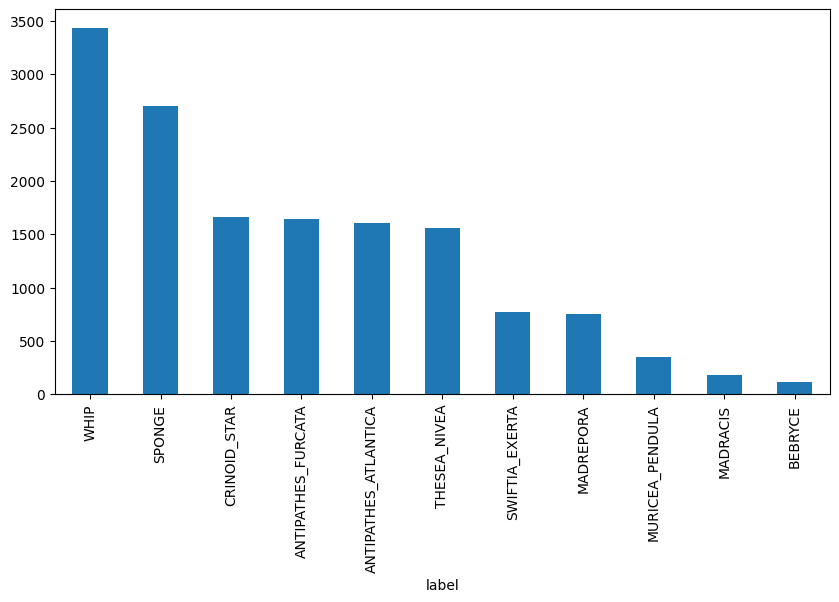

In [12]:
df['label'].value_counts().plot(kind='bar', figsize=(10, 5))

# Convert Data into YOLO-formatted Dataset

In [13]:
# Set parameters
output_dir = "E:/JordanP/Click-a-Coral/data/reduced/MDBC_Transects_Coral_Sponges"
dataset_name = "YOLO_Detection_Dataset"

train_ratio = 0.8
test_ratio = 0.1

task = 'detect' # 'detect' or 'segment'

In [ ]:
df = pd.read_csv(os.path.join(output_dir, "filtered_data.csv"))

In [14]:
# Create and process dataset
dataset = YOLODataset(
    data=df,
    output_dir=output_dir,
    dataset_name=dataset_name,
    train_ratio=train_ratio,
    test_ratio=test_ratio,
    task=task,
    format_class_names=True, 
)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [15]:
# Process the dataset
dataset.process_dataset(move_images=False)  # Makes a copy of the images instead of moving them

Processing YOLO dataset with 14783 annotations...


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Dataset split: 7088 train, 886 valid, 886 test images


Writing detection labels:   0%|          | 0/8860 [00:00<?, ?it/s]

Copying images:   0%|          | 0/8860 [00:00<?, ?it/s]

Dataset created at E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\YOLO_Detection_Dataset
Classes: ['ANTIPATHES_ATLANTICA', 'ANTIPATHES_FURCATA', 'BEBRYCE', 'CRINOID_STAR', 'MADRACIS', 'MADREPORA', 'MURICEA_PENDULA', 'SPONGE', 'SWIFTIA_EXERTA', 'THESEA_NIVEA', 'WHIP']


Rendering Examples:   0%|          | 0/10 [00:00<?, ?it/s]

Rendered 10 examples to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges\YOLO_Detection_Dataset\examples


In [19]:
dataset.dataset_dir

'E:\\JordanP\\Click-a-Coral\\data\\reduced\\MDBC_Transects_Coral_Sponges\\YOLO_Detection_Dataset'

In [20]:
os.path.exists(f"{dataset.dataset_dir}\\data.yaml")

True

# Crop Regions (Optional)

In [21]:
cropper = YOLORegionCropper(dataset_path=f"{dataset.dataset_dir}\\data.yaml", 
                            output_dir=f"{os.path.dirname(dataset.dataset_dir)}",
                            dataset_name="YOLO_Classification_Dataset",
                            format_class_names=False)

In [22]:
# Process the dataset to create classification crops
cropper.process_dataset()

NOTE: Loading dataset...
NOTE: Converting dataset...
Added 7087 images from train dataset
Added 886 images from validation dataset
Added 886 images from test dataset


SupervisionWarnings: Passing a `Dict[str, np.ndarray]` into `DetectionDataset` is deprecated and will be removed in `supervision-0.26.0`. Use a list of paths `List[str]` instead.


NOTE: Loaded dataset - 14781 detections found


Creating crops: 100%|██████████| 8859/8859 [00:54<00:00, 161.16it/s]


Created 14781 crops from 8859 images
NOTE: Writing classification dataset YAML...
Classification dataset YAML written to E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges/YOLO_Classification_Dataset/data.yaml
Class distribution:
  ANTIPATHES_ATLANTICA: train=1148, val=289, test=166
  ANTIPATHES_FURCATA: train=1143, val=331, test=172
  BEBRYCE: train=86, val=21, test=12
  CRINOID_STAR: train=1158, val=334, test=173
  MADRACIS: train=126, val=35, test=19
  MADREPORA: train=558, val=144, test=56
  MURICEA_PENDULA: train=242, val=70, test=37
  SPONGE: train=1914, val=516, test=273
  SWIFTIA_EXERTA: train=528, val=153, test=87
  THESEA_NIVEA: train=1101, val=310, test=145
  WHIP: train=2376, val=701, test=357
NOTE: Created classification dataset in E:\JordanP\Click-a-Coral\data\reduced\MDBC_Transects_Coral_Sponges/YOLO_Classification_Dataset
